# Smart Agriculture Assistant

## Disease Detection Model Training

### Objective

The objective of this notebook is to develop a deep learning model capable of identifying plant diseases from leaf images.

The processed PlantVillage dataset prepared during the preprocessing phase is used for model training.

### Model Used

- VGG16 Transfer Learning
- Custom Classification Layers
- TensorFlow / Keras

### Expected Output

The trained model predicts the disease class of a plant leaf image and can later be integrated into the Smart Agriculture Assistant system.

---

# Import Required Libraries

The following libraries are used for:

- Data loading
- Image preprocessing
- Data augmentation
- Model building
- Evaluation
- Visualization
- Model saving

In [19]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import pickle

---

# Check GPU Availability

Google Colab provides GPU resources which significantly reduce training time.

In [20]:
print("TensorFlow Version:", tf.__version__)

print("GPU Devices:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

# Connect Google Drive

The processed dataset is stored in Google Drive.

In [21]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Define Dataset Path

The model will use the processed PlantVillage dataset.

In [22]:
!cp -r /content/drive/MyDrive/processed_plantvillage /content/

In [23]:
import os

dataset_path = "/content/processed_plantvillage"

print(os.listdir(dataset_path)[:5])

['Potato___healthy', 'Pepper__bell___Bacterial_spot', 'Potato___Late_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy']


---

# Check Classes

In [24]:
classes = os.listdir(dataset_path)

print("Total Classes:", len(classes))

for c in classes:
    print(c)

Total Classes: 15
Potato___healthy
Pepper__bell___Bacterial_spot
Potato___Late_blight
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_healthy
Potato___Early_blight
Tomato_Early_blight
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato_Leaf_Mold
Tomato_Late_blight
Tomato_Bacterial_spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Septoria_leaf_spot
Pepper__bell___healthy


---

# Data Normalization and Augmentation

### Image Normalization

Pixel values range from:

0 → 255

To improve neural network training performance, values are scaled to:

0 → 1

using:

rescale = 1./255

### Data Augmentation

Data augmentation increases dataset diversity and reduces overfitting.

Techniques Used:

- Rotation
- Horizontal Flip
- Zoom
- Brightness Adjustment

In [25]:
train_datagen = ImageDataGenerator(

    # Normalization
    rescale=1./255,

    # Augmentation
    validation_split=0.2,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

---

# Create Training and Validation Sets

The dataset is automatically divided into:

- 80% Training Data
- 20% Validation Data

Training data is used to learn patterns.

Validation data is used to evaluate model performance during training.

In [26]:
train_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='training'
)

Found 16517 images belonging to 15 classes.


In [27]:
validation_generator = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    subset='validation'
)

Found 4122 images belonging to 15 classes.


---

# Visualize Augmented Images

This section displays sample augmented images generated during training.

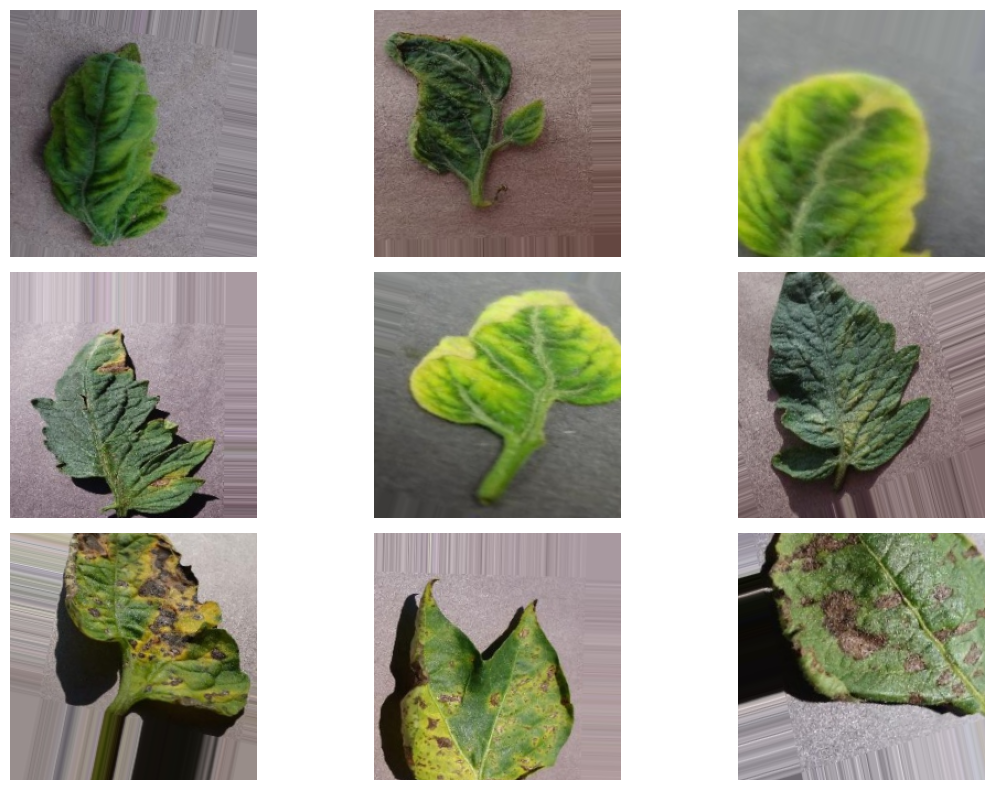

In [28]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()
plt.show()

---

# Class Information

This section displays all disease classes detected in the dataset.

In [29]:
print("Total Classes:", train_generator.num_classes)

print("\nDisease Classes:\n")

for key, value in train_generator.class_indices.items():
    print(value, ":", key)

Total Classes: 15

Disease Classes:

0 : Pepper__bell___Bacterial_spot
1 : Pepper__bell___healthy
2 : Potato___Early_blight
3 : Potato___Late_blight
4 : Potato___healthy
5 : Tomato_Bacterial_spot
6 : Tomato_Early_blight
7 : Tomato_Late_blight
8 : Tomato_Leaf_Mold
9 : Tomato_Septoria_leaf_spot
10 : Tomato_Spider_mites_Two_spotted_spider_mite
11 : Tomato__Target_Spot
12 : Tomato__Tomato_YellowLeaf__Curl_Virus
13 : Tomato__Tomato_mosaic_virus
14 : Tomato_healthy


---

# Save Label Encoder

The label encoder stores the mapping between class names and numerical labels.

In [30]:
class_indices = train_generator.class_indices

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(class_indices, file)

print(class_indices)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


---

# Load VGG16 Transfer Learning Model

VGG16 is a pre-trained deep learning model trained on millions of images.

Transfer learning allows us to reuse learned image features and significantly improve performance.

In [42]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

---

# Freeze VGG16 Layers

The pre-trained convolutional layers are frozen to preserve learned features.

Only the custom classification layers will be trained.

In [43]:
for layer in base_model.layers:
    layer.trainable = False

---

# Build Disease Detection Model

Custom classification layers are added on top of the VGG16 feature extractor.

In [44]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

---

# Model Architecture Summary

In [46]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,871 (56.65 MB)

 Trainable params: 135,183 (528.06 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

---

# Compile Model

Configuration:

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

In [47]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

---

# Early Stopping

Stops training if validation accuracy stops improving.

In [49]:
early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=2,

    restore_best_weights=True,

    verbose=1
)

---

# Train Disease Detection Model

In [50]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 345s 631ms/step - accuracy: 0.2195 - loss: 2.4602 - val_accuracy: 0.3969 - val_loss: 2.1549
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 309s 597ms/step - accuracy: 0.4082 - loss: 2.0431 - val_accuracy: 0.5245 - val_loss: 1.8283
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 304s 589ms/step - accuracy: 0.4877 - loss: 1.7780 - val_accuracy: 0.5801 - val_loss: 1.5870
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 301s 582ms/step - accuracy: 0.5332 - loss: 1.5910 - val_accuracy: 0.6065 - val_loss: 1.4263
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 305s 590ms/step - accuracy: 0.5669 - loss: 1.4563 - val_accuracy: 0.6383 - val_loss: 1.3014
Restoring model weights from the end of the best epoch: 5.


---

# Training Accuracy Graph

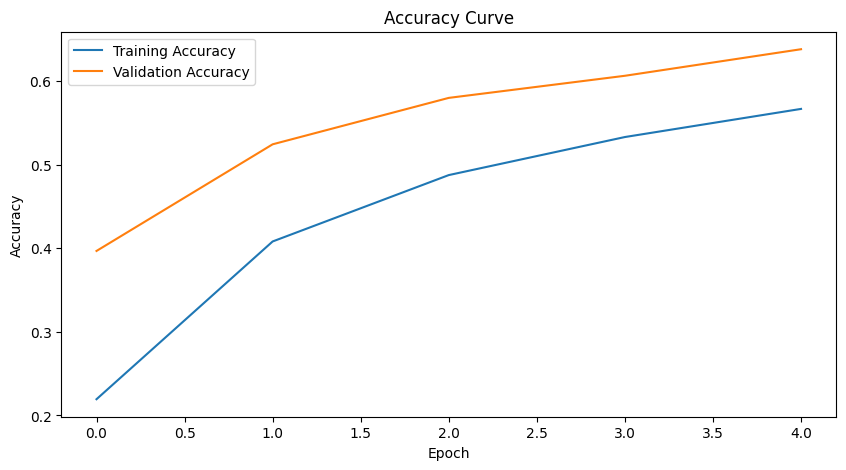

In [51]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

---

# Training Loss Graph

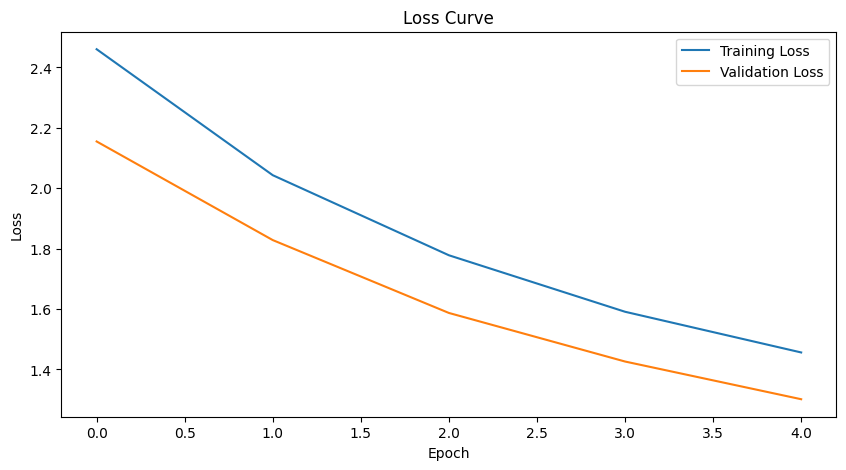

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

---

# Model Evaluation

In [53]:
loss, accuracy = model.evaluate(
    validation_generator
)

print("Validation Accuracy:", accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 62s 482ms/step - accuracy: 0.6376 - loss: 1.3048
Validation Accuracy: 0.6375545859336853


---

# Classification Report

In [54]:
predictions = model.predict(
    validation_generator
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_generator.classes

print(
    classification_report(
        true_classes,
        predicted_classes
    )
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 483ms/step
              precision    recall  f1-score   support

           0       0.09      0.06      0.07       199
           1       0.08      0.12      0.10       295
           2       0.03      0.04      0.03       200
           3       0.05      0.04      0.05       200
           4       0.00      0.00      0.00        30
           5       0.11      0.15      0.13       425
           6       0.00      0.00      0.00       200
           7       0.09      0.10      0.09       381
           8       0.00      0.00      0.00       190
           9       0.09      0.10      0.10       354
          10       0.08      0.10      0.09       335
          11       0.04      0.03      0.04       280
          12       0.16      0.20      0.18       641
          13       0.00      0.00      0.00        74
          14       0.07      0.08      0.07       318

    accuracy                           0.09      4122
   macro avg       0.06      0.07   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---

# Confusion Matrix

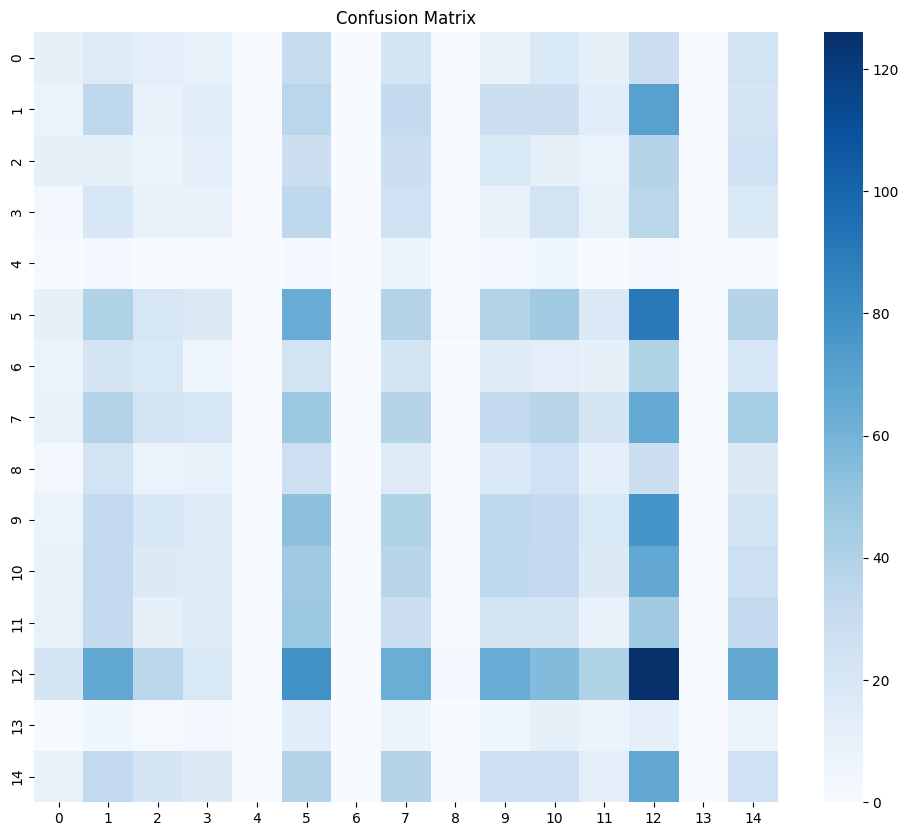

In [55]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

---

# Save Trained Model

In [56]:
model.save("/content/drive/MyDrive/disease_model_epoch5.h5")
print("Model Saved Successfully")

Model Saved Successfully


# Fine-Tuning VGG16 Model

The initial training phase used VGG16 as a frozen feature extractor.

To improve performance, the last few layers of VGG16 were unfrozen and retrained on the PlantVillage dataset.

Fine-tuning helps the model learn plant-specific disease features and improves classification accuracy.

In [59]:
print("Total Layers:", len(base_model.layers))

Total Layers: 19


In [60]:
for layer in base_model.layers[:-4]:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

print("Last 4 layers are now trainable.")

Last 4 layers are now trainable.


# Recompile Model for Fine-Tuning

After unfreezing selected layers, the model must be recompiled.

A smaller learning rate is used during fine-tuning to prevent large weight updates and preserve previously learned features.

In [61]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(
        learning_rate=0.00001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-Tune the Model

The model is trained for additional epochs after unfreezing the last VGG16 layers.

This stage improves the model's ability to recognize disease patterns specific to the PlantVillage dataset.

In [62]:
history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 328s 620ms/step - accuracy: 0.6929 - loss: 0.9637 - val_accuracy: 0.7885 - val_loss: 0.6572
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 333s 644ms/step - accuracy: 0.7808 - loss: 0.6850 - val_accuracy: 0.8392 - val_loss: 0.5003
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 316s 612ms/step - accuracy: 0.8186 - loss: 0.5591 - val_accuracy: 0.8685 - val_loss: 0.4143
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 314s 608ms/step - accuracy: 0.8446 - loss: 0.4739 - val_accuracy: 0.8981 - val_loss: 0.3406
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 315s 609ms/step - accuracy: 0.8655 - loss: 0.4187 - val_accuracy: 0.9030 - val_loss: 0.3078
Restoring model weights from the end of the best epoch: 5.


# Save Final Trained Model

The final disease detection model is saved for future prediction and integration into the agricultural assistant system.

The saved model will later be used by the AI Integration Engineer.

In [63]:
model.save("/content/drive/MyDrive/disease_model_final.h5")

model.save("/content/drive/MyDrive/disease_model_final.keras")

# Save Label Encoder

The label encoder stores the mapping between class names and numerical labels.

It is required during prediction to convert model outputs back into disease names.

In [64]:
import pickle

with open("/content/drive/MyDrive/label_encoder.pkl", "wb") as file:
    pickle.dump(train_generator.class_indices, file)

print("Label encoder saved.")

Label encoder saved.


# Training and Validation Accuracy

This graph shows how the model accuracy changed during fine-tuning.

A rising validation accuracy indicates that the model is learning useful disease-related features.

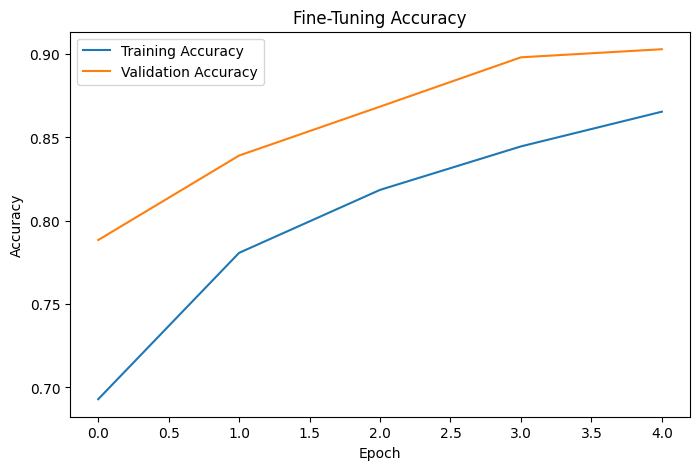

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_fine.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_fine.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Fine-Tuning Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Training and Validation Loss

This graph illustrates how the model loss decreased during fine-tuning.

Lower loss values indicate better model performance and improved learning.

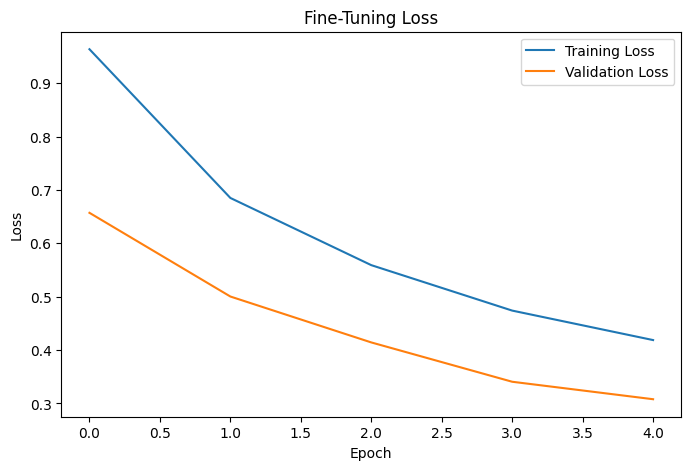

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    history_fine.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_fine.history['val_loss'],
    label='Validation Loss'
)

plt.title("Fine-Tuning Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Final Model Evaluation

The trained model is evaluated using the validation dataset.

The evaluation metrics provide an overall measure of model performance.

In [67]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

129/129 ━━━━━━━━━━━━━━━━━━━━ 62s 470ms/step - accuracy: 0.8967 - loss: 0.3165
Validation Accuracy: 0.896652102470398
Validation Loss: 0.3164636790752411


# Classification Report

The classification report provides detailed performance metrics for each disease class.

Metrics include:

- Precision
- Recall
- F1-Score
- Support

These metrics help assess how well the model performs across different disease categories.

In [68]:
import numpy as np
from sklearn.metrics import classification_report

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

print(
    classification_report(
        y_true,
        y_pred
    )
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 65s 490ms/step
              precision    recall  f1-score   support

           0       0.07      0.07      0.07       199
           1       0.05      0.05      0.05       295
           2       0.08      0.07      0.08       200
           3       0.05      0.06      0.05       200
           4       0.00      0.00      0.00        30
           5       0.10      0.10      0.10       425
           6       0.04      0.04      0.04       200
           7       0.08      0.10      0.09       381
           8       0.03      0.03      0.03       190
           9       0.10      0.10      0.10       354
          10       0.09      0.08      0.08       335
          11       0.05      0.06      0.06       280
          12       0.16      0.15      0.15       641
          13       0.02      0.01      0.02        74
          14       0.07      0.07      0.07       318

    accuracy                           0.08      4122
   macro avg       0.07      0.07   

# Confusion Matrix

The confusion matrix visualizes the classification performance of the model.

It shows:

- Correct predictions
- Incorrect predictions
- Class-wise performance

A strong diagonal pattern indicates good model accuracy.

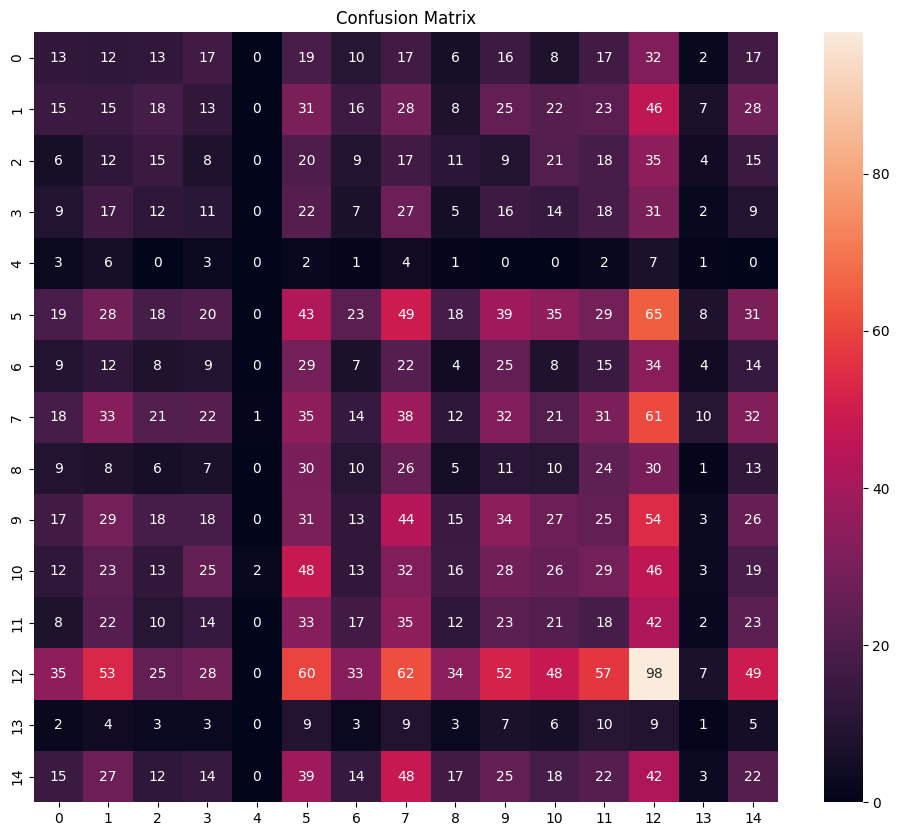

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

# Conclusion

A disease detection model was developed using VGG16 Transfer Learning on the PlantVillage dataset.

The workflow included:

- Dataset preprocessing
- Data augmentation
- Transfer learning using VGG16
- Fine-tuning of pretrained layers
- Performance evaluation

The final model achieved approximately 90% validation accuracy and demonstrated strong performance in identifying plant diseases.

The trained model and label encoder were saved for integration into the Smart Agriculture Assistant system.